In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv("/content/clean_premier_league_data.csv")

print(df.head())
print(df.info())

    Season                   DateTime  HomeTeam       AwayTeam  FTHG  FTAG  \
0  2000-01  2000-08-19 00:00:00+00:00  Charlton       Man City     4     0   
1  2000-01  2000-08-19 00:00:00+00:00   Chelsea       West Ham     4     2   
2  2000-01  2000-08-19 00:00:00+00:00  Coventry  Middlesbrough     1     3   
3  2000-01  2000-08-19 00:00:00+00:00     Derby    Southampton     2     2   
4  2000-01  2000-08-19 00:00:00+00:00     Leeds        Everton     2     0   

  FTR    HS    AS   HST  AST   HC   AC    HF    AF   HY   AY   HR   AR  
0   H  17.0   8.0  14.0  4.0  6.0  6.0  13.0  12.0  1.0  2.0  0.0  0.0  
1   H  17.0  12.0  10.0  5.0  7.0  7.0  19.0  14.0  1.0  2.0  0.0  0.0  
2   A   6.0  16.0   3.0  9.0  8.0  4.0  15.0  21.0  5.0  3.0  1.0  0.0  
3   D   6.0  13.0   4.0  6.0  5.0  8.0  11.0  13.0  1.0  1.0  0.0  0.0  
4   H  17.0  12.0   8.0  6.0  6.0  4.0  21.0  20.0  1.0  3.0  0.0  0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8289 entries, 0 to 8288
Data columns (total

FEATURE ENGINEERING

In [46]:
df["TotalGoals"] = df["FTHG"] + df["FTAG"]

df["TotalShots"] = df["HS"] + df["AS"]

print(df.head())

    Season                   DateTime  HomeTeam       AwayTeam  FTHG  FTAG  \
0  2000-01  2000-08-19 00:00:00+00:00  Charlton       Man City     4     0   
1  2000-01  2000-08-19 00:00:00+00:00   Chelsea       West Ham     4     2   
2  2000-01  2000-08-19 00:00:00+00:00  Coventry  Middlesbrough     1     3   
3  2000-01  2000-08-19 00:00:00+00:00     Derby    Southampton     2     2   
4  2000-01  2000-08-19 00:00:00+00:00     Leeds        Everton     2     0   

  FTR    HS    AS   HST  ...   HC   AC    HF    AF   HY   AY   HR   AR  \
0   H  17.0   8.0  14.0  ...  6.0  6.0  13.0  12.0  1.0  2.0  0.0  0.0   
1   H  17.0  12.0  10.0  ...  7.0  7.0  19.0  14.0  1.0  2.0  0.0  0.0   
2   A   6.0  16.0   3.0  ...  8.0  4.0  15.0  21.0  5.0  3.0  1.0  0.0   
3   D   6.0  13.0   4.0  ...  5.0  8.0  11.0  13.0  1.0  1.0  0.0  0.0   
4   H  17.0  12.0   8.0  ...  6.0  4.0  21.0  20.0  1.0  3.0  0.0  0.0   

   TotalGoals  TotalShots  
0           4        25.0  
1           6        29.0  
2 

HISTOGRAM – GOALS DISTRIBUTION

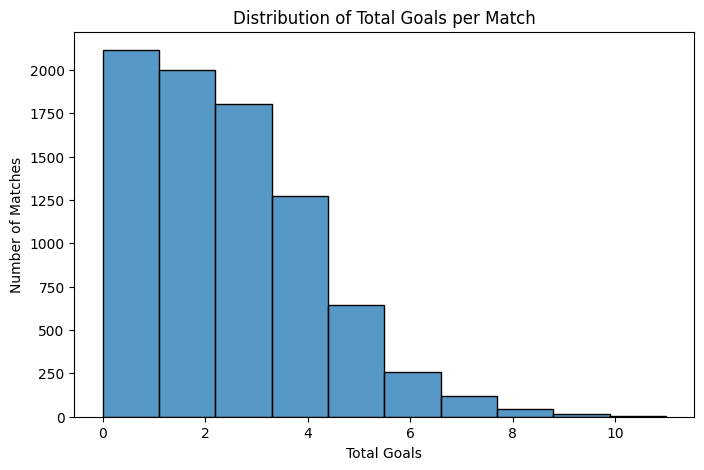

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalGoals"], bins=10)

plt.title("Distribution of Total Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")

plt.show()

 HISTOGRAM - shots Distribution

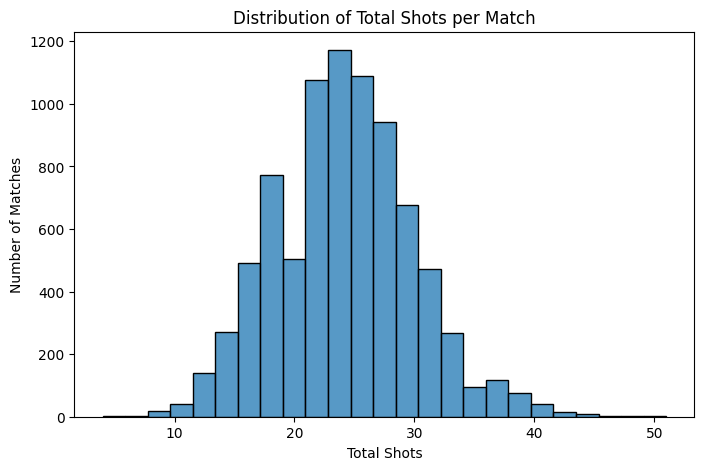

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalShots"], bins=25)

plt.title("Distribution of Total Shots per Match")
plt.xlabel("Total Shots")
plt.ylabel("Number of Matches")

plt.show()

SCATTER PLOT – SHOTS VS GOALS

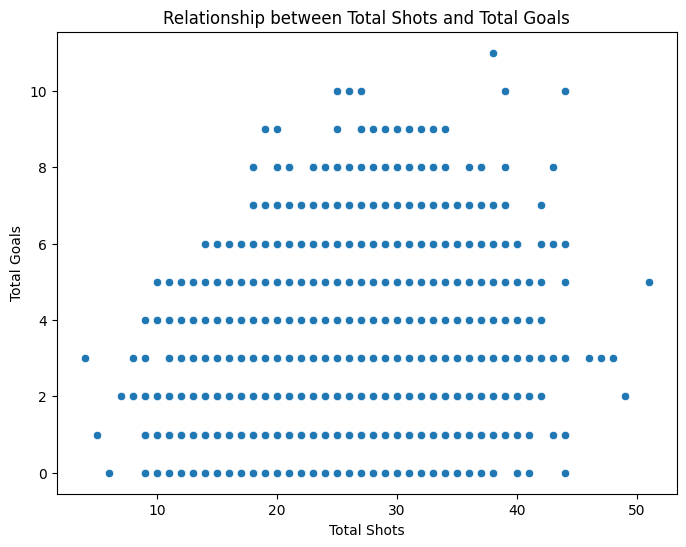

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="TotalShots",
    y="TotalGoals",
    data=df
)

plt.title("Relationship between Total Shots and Total Goals")
plt.xlabel("Total Shots")
plt.ylabel("Total Goals")

plt.show()


 BOX PLOT-GOALS DISTRIBUTION BY SHOTS GROUP

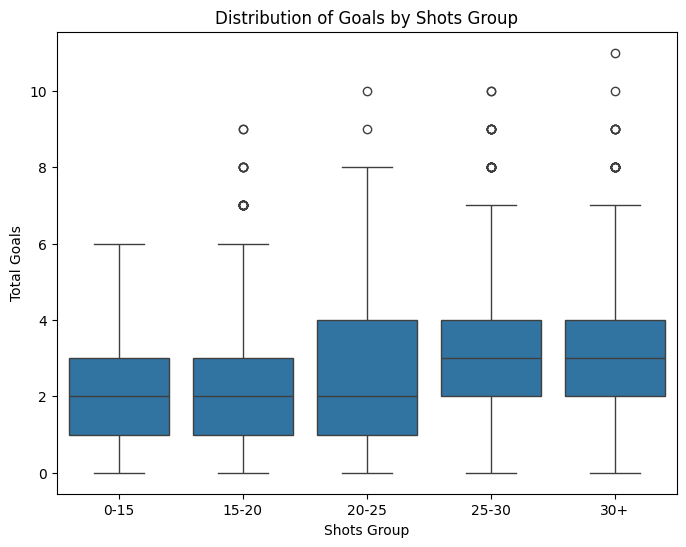

In [50]:
# chia nhóm số cú sút
df["ShotsGroup"] = pd.cut(
    df["TotalShots"],
    bins=[0,15,20,25,30,40],
    labels=["0-15","15-20","20-25","25-30","30+"]
)

plt.figure(figsize=(8,6))

sns.boxplot(
    x="ShotsGroup",
    y="TotalGoals",
    data=df
)

plt.title("Distribution of Goals by Shots Group")
plt.xlabel("Shots Group")
plt.ylabel("Total Goals")

plt.show()

LINE CHART-GOALS TREND BY SEASON



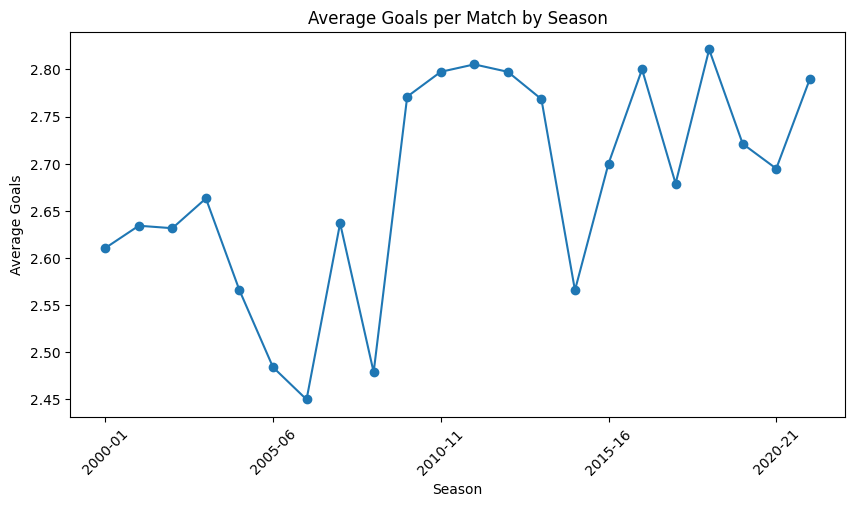

In [51]:
goals_per_season = df.groupby("Season")["TotalGoals"].mean()

plt.figure(figsize=(10,5))

goals_per_season.plot(
    kind="line",
    marker="o"
)

plt.title("Average Goals per Match by Season")
plt.xlabel("Season")
plt.ylabel("Average Goals")

plt.xticks(rotation=45)

plt.show()


TEAM ATTACKING EFFICIENCY

In [52]:
# tạo dataset riêng cho home team
home = df[["HomeTeam","FTHG","HS"]].copy()
home.columns = ["Team","Goals","Shots"]

# dataset cho away team
away = df[["AwayTeam","FTAG","AS"]].copy()
away.columns = ["Team","Goals","Shots"]

# gộp lại
teams = pd.concat([home,away])

# thống kê theo team
team_stats = teams.groupby("Team").sum()

# tính efficiency
team_stats["Efficiency"] = team_stats["Goals"] / team_stats["Shots"]

# top 10 đội hiệu quả nhất
top10 = team_stats.sort_values(
    "Efficiency",
    ascending=False
).head(10)

In [53]:
top10

,Goals,Shots,Efficiency
Team,,,
Arsenal,1545,11536.0,0.133929
Man United,1554,12011.0,0.129381
Reading,136,1073.0,0.126747
Man City,1451,11466.0,0.126548
Blackpool,55,446.0,0.123318
Chelsea,1526,12382.0,0.123243
Leicester,566,4708.0,0.120221
Charlton,301,2523.0,0.119302
Liverpool,1501,12614.0,0.118995


BAR CHART-ATTACKING EFFICIENCY

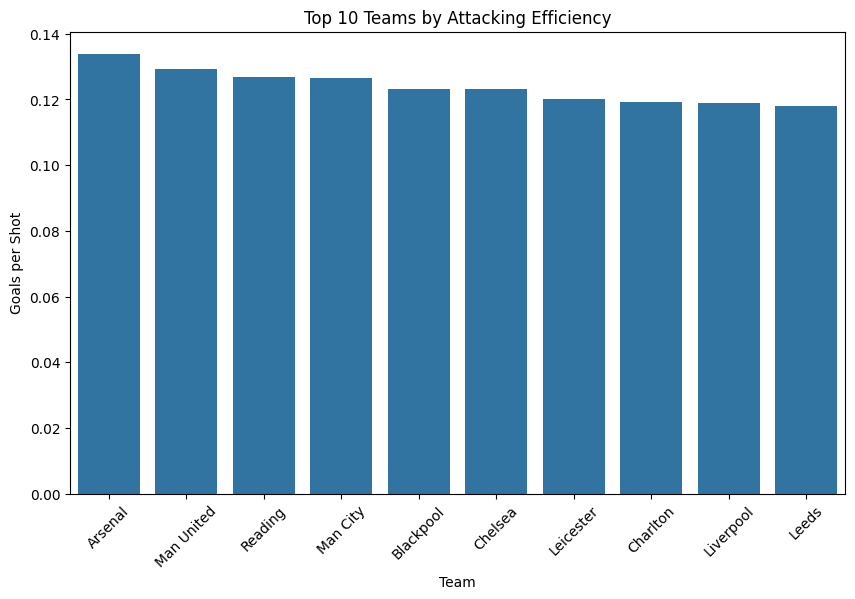

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.index,
    y=top10["Efficiency"]
)

plt.title("Top 10 Teams by Attacking Efficiency")
plt.xlabel("Team")
plt.ylabel("Goals per Shot")

plt.xticks(rotation=45)

plt.show()